## Function 3: Transform Coordinate Systems 🔄

In this notebook, you'll learn how to build the `transform_crs()` function step by step. This is like converting a spatial dataset from one coordinate system to another so it can be used correctly for mapping, measurement, and analysis.

### 🎯 What This Function Does
- Transform data between coordinate systems
- Work with EPSG codes and CRS strings
- Validate CRS before transformation
- Handle projection errors
- Choose appropriate CRS for analysis

### 🔧 Function Signature
```python
def transform_crs(gdf, target_crs):
    """
    Args:
        gdf (geopandas.GeoDataFrame): Input spatial dataset
        target_crs (str or int): Target coordinate reference system
    
    Returns:
        geopandas.GeoDataFrame: A transformed GeoDataFrame in the target CRS
    """
```

### 📍 Where This Function Goes:
**Target File**: `src/geopandas_basics.py`  
**Function Name**: `transform_crs()`  
**Replace**: The placeholder function with your working code

---

### ⚙️ Step 0: Select the Correct Python Kernel

Before running any cells, make sure the notebook is using the correct Python environment.

**Check the kernel in the top-right corner of the notebook.**

The correct Python environment is **python-gis-development (.venv)**  
It may appear with a Python version, for example:  
**python-gis-development (3.11.15) (Python 3.11.15) .venv/bin/python**



If the kernel is **python-gis-development (.venv)**, you can start running cells below.

Steps to select the correct kernel:
1. Click on the kernel (top right corner of the notebook) if it is not **python-gis-development (.venv)** or if it says "Select Kernel"
2. Select **python-gis-development (.venv)**
3. If you do not see the kernel in the list, click on "Select Another Kernel..."  
    a. Click on Python Environments...   
    b. Select **python-gis-development (.venv)**

Once the correct kernel is selected, you can start running cells below.

### 📚 Step 1: Why CRS Transformations Matter

Different CRS have different properties:

| CRS | EPSG | Use Case | Distortion |
|-----|------|----------|------------|
| WGS84 | 4326 | GPS, Web maps | Angles preserved (lat/lon) |
| Web Mercator | 3857 | Web mapping | Area distorted at poles |
| UTM Zones | 326XX | Local measurements | Accurate within zone |

**Key Insight:** You MUST use projected CRS (meters) for accurate distance/area calculations!

### 💻 Step 2: Load Data and Check CRS

In [7]:
import geopandas as gpd
from typing import Union

# Load cities
cities = gpd.read_file('../../data/cities/ne_cities_us.geojson')

print(f"Original CRS: {cities.crs}")
print(f"CRS is defined? {cities.crs is not None}")
print(f"First city location: {cities.geometry.iloc[0]}")

Original CRS: EPSG:4326
CRS is defined? True
First city location: POINT (-73.99571754361698 40.72156174972766)


### 🔄 Step 3: Basic CRS Transformation

**💡 This is the core operation in our function!**

In [8]:
# 💡 Transform using .to_crs() method
cities_mercator = cities.to_crs('EPSG:3857')  # Web Mercator

print(f"Original CRS: {cities.crs}")
print(f"New CRS: {cities_mercator.crs}")
print()

# Compare coordinates
print(f"Original (lat/lon): {cities.geometry.iloc[0]}")
print(f"Transformed (meters): {cities_mercator.geometry.iloc[0]}")

Original CRS: EPSG:4326
New CRS: EPSG:3857

Original (lat/lon): POINT (-73.99571754361698 40.72156174972766)
Transformed (meters): POINT (-8237165.597838341 4971358.429174842)


### 🗺️ Step 4: Visualization 1 - Side-by-Side CRS Comparison

See how projections change the appearance of the SAME data

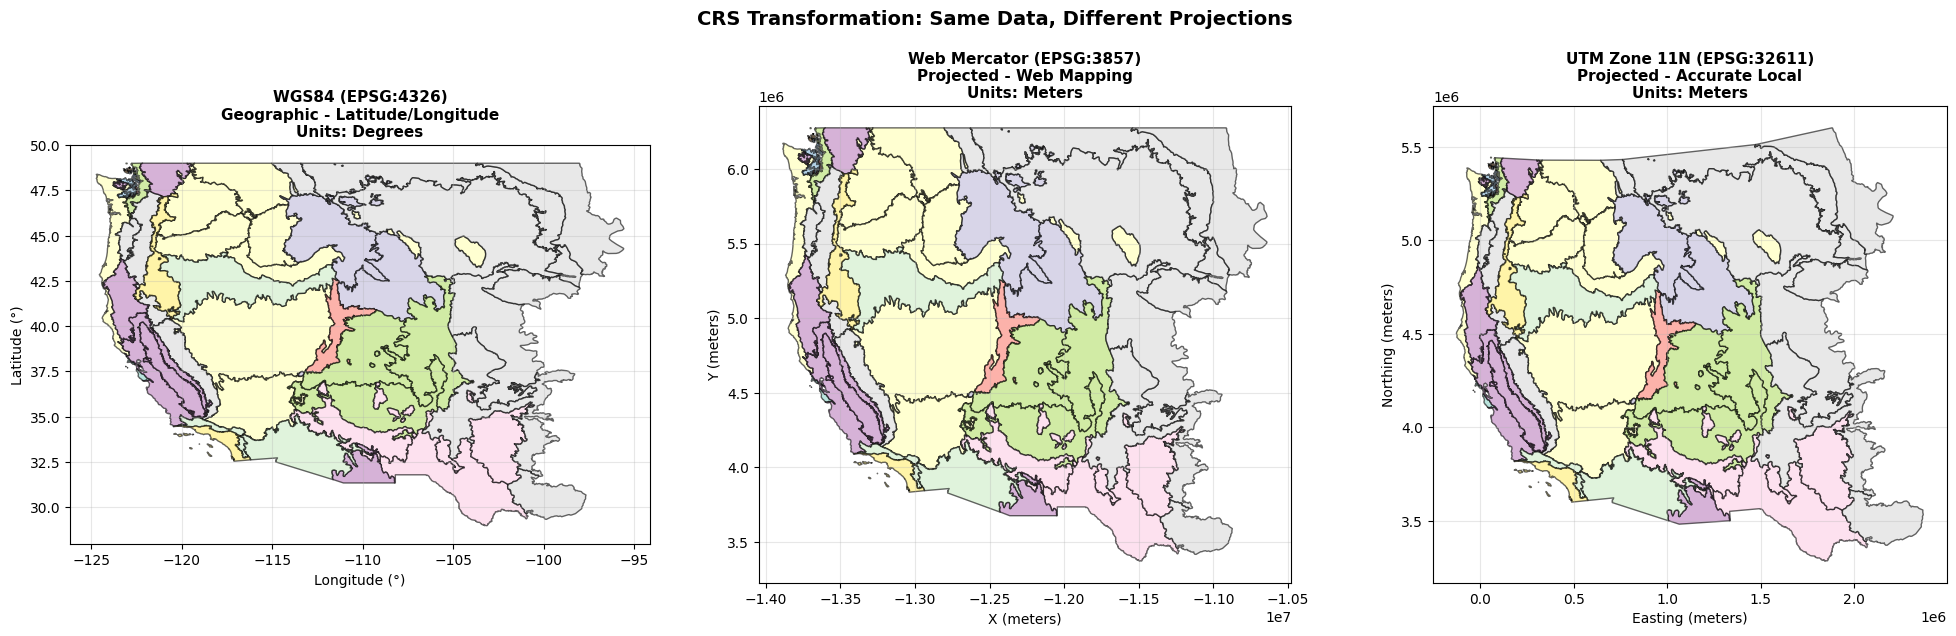

🎯 Key Observations:
   ├─ Same geographic area shown three ways
   ├─ Shape appears different due to projection method
   ├─ Geographic (WGS84): Good for global data, lat/lon
   ├─ Web Mercator: Standard for web maps (Google, OSM)
   └─ UTM: Best for accurate local measurements in meters


In [9]:
import matplotlib.pyplot as plt

# Load ecoregions for better visualization
ecoregions = gpd.read_file('../../data/ecoregions/epa_level3_western_us.geojson')

# Create three common CRS versions
gdf_wgs84 = ecoregions.to_crs('EPSG:4326')      # Geographic
gdf_mercator = ecoregions.to_crs('EPSG:3857')   # Web Mercator
gdf_utm = ecoregions.to_crs('EPSG:32611')       # UTM Zone 11N

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

# WGS84 (Geographic)
gdf_wgs84.plot(ax=ax1, alpha=0.6, edgecolor='black', linewidth=1, cmap='Set3')
ax1.set_title("WGS84 (EPSG:4326)\nGeographic - Latitude/Longitude\nUnits: Degrees", 
             fontsize=11, fontweight='bold')
ax1.set_xlabel("Longitude (°)")
ax1.set_ylabel("Latitude (°)")
ax1.set_aspect('equal')
ax1.grid(True, alpha=0.3)

# Web Mercator
gdf_mercator.plot(ax=ax2, alpha=0.6, edgecolor='black', linewidth=1, cmap='Set3')
ax2.set_title("Web Mercator (EPSG:3857)\nProjected - Web Mapping\nUnits: Meters", 
             fontsize=11, fontweight='bold')
ax2.set_xlabel("X (meters)")
ax2.set_ylabel("Y (meters)")
ax2.set_aspect('equal')
ax2.grid(True, alpha=0.3)

# UTM Zone 11N
gdf_utm.plot(ax=ax3, alpha=0.6, edgecolor='black', linewidth=1, cmap='Set3')
ax3.set_title("UTM Zone 11N (EPSG:32611)\nProjected - Accurate Local\nUnits: Meters", 
             fontsize=11, fontweight='bold')
ax3.set_xlabel("Easting (meters)")
ax3.set_ylabel("Northing (meters)")
ax3.set_aspect('equal')
ax3.grid(True, alpha=0.3)

plt.suptitle("CRS Transformation: Same Data, Different Projections", 
            fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("🎯 Key Observations:")
print("   ├─ Same geographic area shown three ways")
print("   ├─ Shape appears different due to projection method")
print("   ├─ Geographic (WGS84): Good for global data, lat/lon")
print("   ├─ Web Mercator: Standard for web maps (Google, OSM)")
print("   └─ UTM: Best for accurate local measurements in meters")


### 🗺️ Step 5: Visualization 2 - Tracking One City Across CRS

📍 Tracking Los Angeles through CRS transformations:

WGS84 (EPSG:4326):
  Longitude: -118.231986°
  Latitude:  34.049219°
  → Human-readable lat/lon

Web Mercator (EPSG:3857):
  X: -13,161,524.53 meters
  Y: 4,035,412.89 meters
  → Good for web maps

UTM Zone 11N (EPSG:32611):
  Easting:  386,291.08 meters
  Northing: 3,768,297.88 meters
  → Best for accurate distance/area



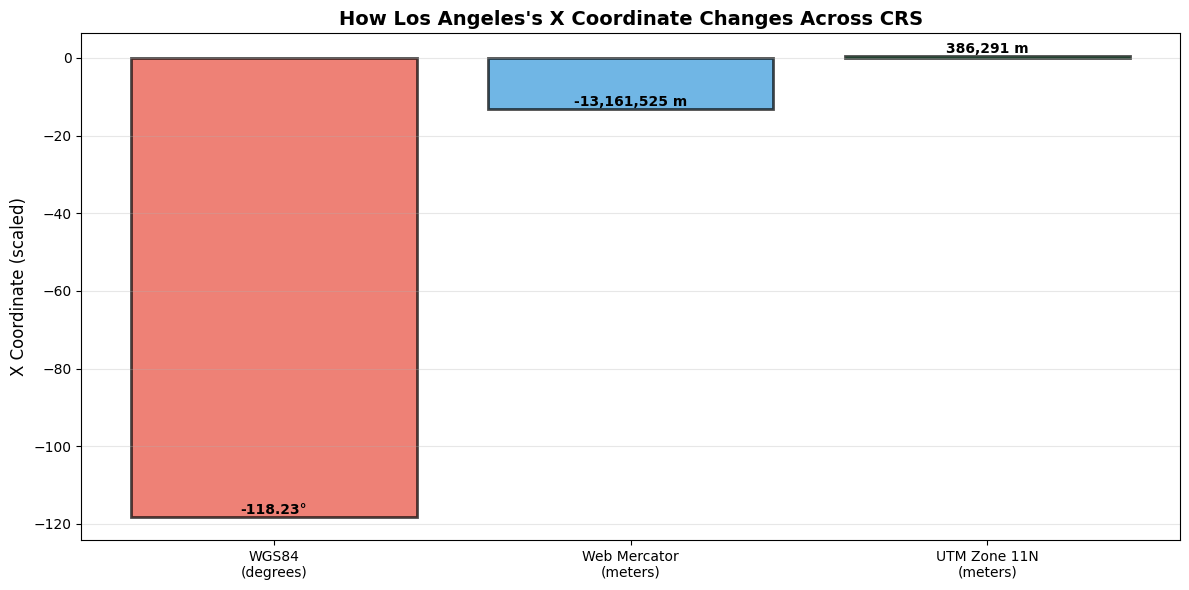

🎯 Notice: Same location, VERY different coordinate values!


In [10]:
# Pick one city to track
city_name = "Los Angeles"
la = cities[cities['name'].str.contains(city_name, case=False)].iloc[0]

# Transform to different CRS
la_wgs84 = cities[cities['name'].str.contains(city_name, case=False)].to_crs('EPSG:4326').iloc[0]
la_mercator = cities[cities['name'].str.contains(city_name, case=False)].to_crs('EPSG:3857').iloc[0]
la_utm = cities[cities['name'].str.contains(city_name, case=False)].to_crs('EPSG:32611').iloc[0]

# Extract coordinates
wgs84_coords = (la_wgs84.geometry.x, la_wgs84.geometry.y)
mercator_coords = (la_mercator.geometry.x, la_mercator.geometry.y)
utm_coords = (la_utm.geometry.x, la_utm.geometry.y)

print(f"📍 Tracking {city_name} through CRS transformations:\n")
print("WGS84 (EPSG:4326):")
print(f"  Longitude: {wgs84_coords[0]:.6f}°")
print(f"  Latitude:  {wgs84_coords[1]:.6f}°")
print("  → Human-readable lat/lon\n")

print("Web Mercator (EPSG:3857):")
print(f"  X: {mercator_coords[0]:,.2f} meters")
print(f"  Y: {mercator_coords[1]:,.2f} meters")
print("  → Good for web maps\n")

print("UTM Zone 11N (EPSG:32611):")
print(f"  Easting:  {utm_coords[0]:,.2f} meters")
print(f"  Northing: {utm_coords[1]:,.2f} meters")
print("  → Best for accurate distance/area\n")

# Visualize the coordinate transformation
fig, ax = plt.subplots(figsize=(12, 6))

crs_names = ['WGS84\n(degrees)', 'Web Mercator\n(meters)', 'UTM Zone 11N\n(meters)']
x_coords = [wgs84_coords[0], mercator_coords[0]/1e6, utm_coords[0]/1e6]  # Scale for visibility
colors = ['#e74c3c', '#3498db', '#2ecc71']

bars = ax.bar(crs_names, x_coords, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('X Coordinate (scaled)', fontsize=12)
ax.set_title(f"How {city_name}'s X Coordinate Changes Across CRS", fontsize=14, fontweight='bold')
ax.grid(True, axis='y', alpha=0.3)

# Add value labels
for bar, val, orig, name in zip(bars, x_coords, [wgs84_coords[0], mercator_coords[0], utm_coords[0]], crs_names):
    height = bar.get_height()
    if 'degrees' in name:
        label = f'{orig:.2f}°'
    else:
        label = f'{orig:,.0f} m'
    ax.text(bar.get_x() + bar.get_width()/2., height,
           label,
           ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("🎯 Notice: Same location, VERY different coordinate values!")


### 🗺️ Step 6: Visualization 3 - Why CRS Matters for Measurements

Let's see how CRS affects AREA calculations.

/tmp/ipykernel_4389/1948084956.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  area_wgs84 = gdf_wgs84.geometry.area.sum()
/workspaces/gist604b-python/.venv/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/workspaces/gist604b-python/.venv/lib/python3.11/site-packages/geopandas/plotting.py:480: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  ax.figure.canvas.draw_idle()
/tmp/ipykernel_4389/1948084956.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/workspaces/gist604b-python/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.pr

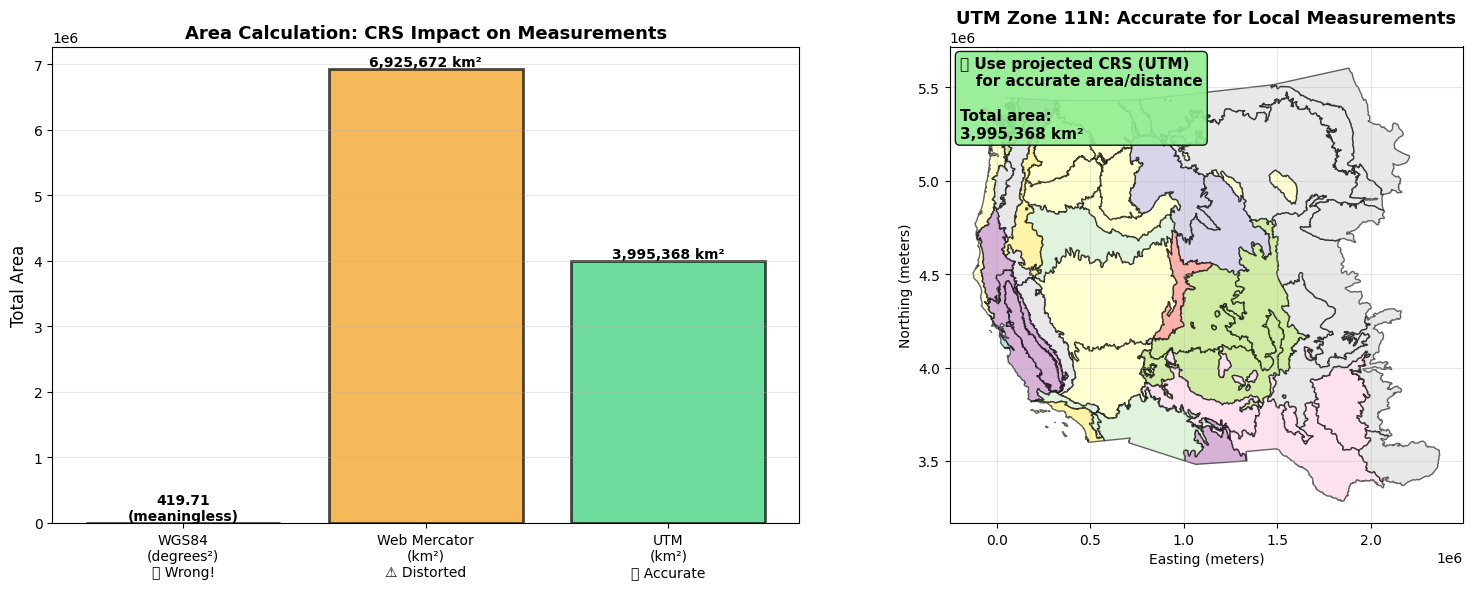

🎯 Critical Lesson:
   ├─ WGS84 (degrees²): 419.71 ← MEANINGLESS!
   ├─ Web Mercator: 6,925,672 km² ← Distorted (especially at poles)
   └─ UTM Zone 11N: 3,995,368 km² ← ACCURATE for this region!

   ⚠️  ALWAYS use projected CRS (meters) for measurements!
   ✅ Never calculate area/distance in degrees!


In [11]:
# Calculate total area in different CRS
area_wgs84 = gdf_wgs84.geometry.area.sum()
area_mercator = gdf_mercator.geometry.area.sum()
area_utm = gdf_utm.geometry.area.sum()

# Convert to km²
area_mercator_km2 = area_mercator / 1_000_000
area_utm_km2 = area_utm / 1_000_000

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# LEFT: Bar chart comparing areas
crs_labels = ['WGS84\n(degrees²)\n❌ Wrong!', 
             'Web Mercator\n(km²)\n⚠️ Distorted', 
             'UTM\n(km²)\n✅ Accurate']
areas = [area_wgs84, area_mercator_km2, area_utm_km2]
colors = ['#e74c3c', '#f39c12', '#2ecc71']

bars = ax1.bar(crs_labels, areas, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Total Area', fontsize=12)
ax1.set_title('Area Calculation: CRS Impact on Measurements', fontsize=13, fontweight='bold')
ax1.grid(True, axis='y', alpha=0.3)

# Add value labels
for bar, area in zip(bars, areas):
    height = bar.get_height()
    if area < 1000:
        label = f'{area:.2f}\n(meaningless)'
    else:
        label = f'{area:,.0f} km²'
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            label,
            ha='center', va='bottom', fontsize=10, fontweight='bold')

# RIGHT: Map showing UTM zone (the accurate one)
gdf_utm.plot(ax=ax2, alpha=0.6, edgecolor='black', linewidth=1, cmap='Set3', legend=False)
ax2.set_title('UTM Zone 11N: Accurate for Local Measurements', fontsize=13, fontweight='bold')
ax2.set_xlabel('Easting (meters)')
ax2.set_ylabel('Northing (meters)')
ax2.grid(True, alpha=0.3)

# Add informative text
info_text = "✅ Use projected CRS (UTM)\n   for accurate area/distance\n\n"
info_text += f"Total area:\n{area_utm_km2:,.0f} km²"
ax2.text(0.02, 0.98, info_text,
        transform=ax2.transAxes,
        verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.9),
        fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("🎯 Critical Lesson:")
print(f"   ├─ WGS84 (degrees²): {area_wgs84:.2f} ← MEANINGLESS!")
print(f"   ├─ Web Mercator: {area_mercator_km2:,.0f} km² ← Distorted (especially at poles)")
print(f"   └─ UTM Zone 11N: {area_utm_km2:,.0f} km² ← ACCURATE for this region!")
print("\n   ⚠️  ALWAYS use projected CRS (meters) for measurements!")
print("   ✅ Never calculate area/distance in degrees!")


**🎯 Key Takeaways:**
- **Never measure in degrees!** (WGS84/EPSG:4326 gives meaningless area values)
- **Use projected CRS** (EPSG:3857, UTM zones) for accurate distance/area
- **Choose the right projection** for your region (UTM zones are zone-specific)
- **Transformation is essential** before spatial analysis

**Rule of thumb:**
- 📍 Loading data → Keep WGS84 (EPSG:4326) 
- 📏 Measuring/analyzing → Transform to projected CRS (UTM or meters)
- 🗺️ Web mapping → Transform to Web Mercator (EPSG:3857)

**Notice:** Coordinates changed from degrees to meters!

### ⚠️ Step 7: Validating Input CRS

**💡 This check prevents transformation errors!**

In [12]:
# 💡 Always check if GeoDataFrame has CRS before transforming
gdf = cities.copy()

if gdf.crs is None:
    print("❌ Error: No CRS defined! Cannot transform.")
    # In function: raise ValueError("Input GeoDataFrame has no CRS defined. Cannot transform.")
else:
    print(f"✅ CRS is defined: {gdf.crs}")
    print("   Safe to transform!")

# What if CRS is missing?
no_crs_gdf = gpd.GeoDataFrame(geometry=cities.geometry)
print(f"\nGeoDataFrame without CRS: {no_crs_gdf.crs}")
print(f"Is None? {no_crs_gdf.crs is None}")

✅ CRS is defined: EPSG:4326
   Safe to transform!

GeoDataFrame without CRS: EPSG:4326
Is None? False


### 🛡️ Step 8: Handling Invalid Target CRS

**💡 This handles transformation errors!**

In [13]:
# 💡 Use try/except to catch invalid CRS errors
target_crs = 'EPSG:3857'  # Valid

try:
    result = cities.to_crs(target_crs)
    print(f"✅ Successfully transformed to {result.crs}")
except Exception as e:
    print(f"❌ Transformation failed: {e}")
    # In function: raise ValueError(f"Invalid target CRS '{target_crs}': {str(e)}")

# Try invalid CRS
print("\nTrying invalid CRS:")
try:
    result = cities.to_crs('INVALID:9999')
except Exception as e:
    print(f"❌ Failed as expected: {str(e)[:100]}...")

✅ Successfully transformed to EPSG:3857

Trying invalid CRS:
❌ Failed as expected: Invalid projection: INVALID:9999: (Internal Proj Error: proj_create: crs not found: INVALID:9999)...


### 🏗️ Step 9: Building the Complete Function

Now let's put everything together into a reusable function. This is what you will implement in `src/geopandas_basics.py`.

In [14]:
import geopandas as gpd
from typing import Union

def transform_crs(
    gdf: gpd.GeoDataFrame, 
    target_crs: Union[str, int]
) -> gpd.GeoDataFrame:
    """
    Transform GeoDataFrame to a different coordinate reference system.
    
    Handles CRS transformation with proper validation and error handling.
    Essential for ensuring spatial data alignment and accurate measurements.
    
    Args:
        gdf: Input GeoDataFrame
        target_crs: Target CRS (e.g., 'EPSG:4326', 'EPSG:3857', or EPSG code as int)
        
    Returns:
        New GeoDataFrame in the target CRS
        
    Raises:
        ValueError: If GeoDataFrame has no CRS or target CRS is invalid
        
    Example:
        >>> # Transform to Web Mercator (EPSG:3857)
        >>> gdf_mercator = transform_crs(gdf, 'EPSG:3857')
        >>> print(f"New CRS: {gdf_mercator.crs}")
    """
    # Check if input has CRS
    if gdf.crs is None:
        raise ValueError("Input GeoDataFrame has no CRS defined. Cannot transform.")
    
    # Validate target CRS by trying to transform
    try:
        result = gdf.to_crs(target_crs)
    except Exception as e:
        raise ValueError(f"Invalid target CRS '{target_crs}': {str(e)}")
    
    return result

### ✨ Step 10: Test Your Function

Let's test our complete function with different scenarios:

In [16]:
# Test 1: Transform to Web Mercator
print("Test 1: Transform to Web Mercator")
cities_merc = transform_crs(cities, 'EPSG:3857')
print(f"✅ Original: {cities.crs}")
print(f"✅ Transformed: {cities_merc.crs}")
print()

# Test 2: Transform using integer EPSG code
print("Test 2: Using integer EPSG code")
cities_utm = transform_crs(cities, 32611)  # UTM Zone 11N
print(f"✅ Transformed to: {cities_utm.crs}")
print()

# Test 3: Error handling - no CRS
print("Test 3: Error handling (no CRS)")
no_crs_gdf = cities.copy()
no_crs_gdf = no_crs_gdf.set_crs(None, allow_override=True)
try:
    transform_crs(no_crs_gdf, 'EPSG:3857')
    print("❌ Should have raised ValueError")
except ValueError as e:
    print("✅ Correctly raised ValueError")
    print(f"   Message: {e}")
print()

# Test 4: Error handling - invalid target CRS
print("Test 4: Error handling (invalid target CRS)")
try:
    transform_crs(cities, 'INVALID:9999')
    print("❌ Should have raised ValueError")
except ValueError as e:
    print("✅ Correctly raised ValueError")
    print(f"   Message: {str(e)[:80]}...")
print()

print("🎉 All tests passed!")

Test 1: Transform to Web Mercator
✅ Original: EPSG:4326
✅ Transformed: EPSG:3857

Test 2: Using integer EPSG code
✅ Transformed to: EPSG:32611

Test 3: Error handling (no CRS)
✅ Correctly raised ValueError
   Message: Input GeoDataFrame has no CRS defined. Cannot transform.

Test 4: Error handling (invalid target CRS)
✅ Correctly raised ValueError
   Message: Invalid target CRS 'INVALID:9999': Invalid projection: INVALID:9999: (Internal P...

🎉 All tests passed!


### 🧪 Step 11: Verify with Pytest

Test your entire function to verify your implementation in `src/geopandas_basics.py` by running the following line in the terminal

```bash
uv run pytest tests/ -k "TestTransformCRS" -v
```

**⚠️ IMPORTANT: Make sure this passes before you move on!**

---

### 🔑 Key Learning Points

- **`.to_crs()`** transforms a GeoDataFrame into a new coordinate reference system
- Always check whether a dataset has a defined CRS before transforming it
- **Projected CRS** are needed for accurate distance and area calculations
- **EPSG codes** can be provided as strings like `"EPSG:3857"` or integers like `3857`
- Use **`try/except`** to handle invalid target CRS values gracefully
- CRS transformations help align datasets for analysis and mapping
- Choosing the right CRS depends on whether you are mapping, measuring, or doing web visualization